## Name: Aryan Mahesh Patil
### Rollno: 46
#### Subject: DL
#### Experiment No: 3

In [67]:
#pip install scikit-learn
#pip install matplotlib notebook

In [68]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [69]:
X, Y= make_moons(n_samples=200, noise=0.2,random_state=42)

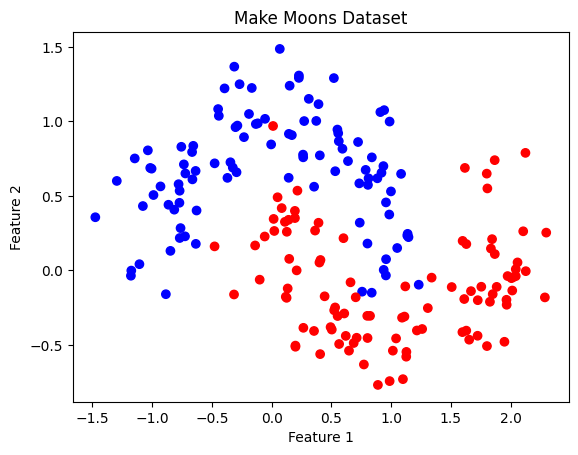

In [70]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1],c=Y,cmap='bwr')
plt.title("Make Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [71]:
X=torch.FloatTensor(X)
Y=torch.FloatTensor(Y).view(-1,1)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [72]:
model=nn.Sequential(
    nn.Linear(2,1),
    nn.Sigmoid()
)

In [73]:
criterion=nn.BCELoss()
optimizer=optim.SGD(model.parameters(),lr=0.1)
for epoch in range(1000):
    output=model(X_train)
    loss=criterion(output, Y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
with torch.no_grad():
    output=model(X_train)
    prediction=(output>=0.5).float()

print("Predictions")
print(prediction)

Predictions
tensor([[0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        

In [74]:
accuracy = (prediction == Y_train).float().mean() * 100
print("\nTrain Accuracy =", accuracy.item(), "%")


Train Accuracy = 84.375 %


In [75]:
with torch.no_grad():
    output=model(X_test)
    prediction=(output>=0.5).float()

In [76]:
accuracy = (prediction == Y_test).float().mean() * 100
print("\nTest Accuracy =", accuracy.item(), "%")


Test Accuracy = 85.0 %


In [103]:
def train_model(hidden_neurons):
    model=nn.Sequential(
    nn.Linear(2,hidden_neurons),
    nn.ReLU(),
    nn.Linear(hidden_neurons,1),
    nn.Sigmoid()
    )
    criterion=nn.BCELoss()
    optimizer=optim.Adam(model.parameters(), lr=0.01)
    for epoch in range(1000):
        output=model(X_train)
        loss=criterion(output, Y_train)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    with torch.no_grad():
        output=model(X_train)
        prediction=(output>=0.5).float()
    
    accuracy = (prediction == Y_train).float().mean() * 100
    print("\nTrain Accuracy =", accuracy.item(), "%")

    with torch.no_grad():
        output=model(X_test)
        prediction=(output>=0.5).float()
    test_accuracy = (prediction == Y_test).float().mean() * 100
    print("\nTest Accuracy =", test_accuracy.item(), "%")
    return accuracy

In [116]:
neurons=[2,4,8,16,32,64]
accuracy=[]

In [117]:
accuracy.append(train_model(2))


Train Accuracy = 83.125 %

Test Accuracy = 82.5 %


In [118]:
accuracy.append(train_model(4))


Train Accuracy = 88.125 %

Test Accuracy = 87.5 %


In [119]:
accuracy.append(train_model(8))


Train Accuracy = 98.125 %

Test Accuracy = 92.5 %


In [120]:
accuracy.append(train_model(16))


Train Accuracy = 98.75 %

Test Accuracy = 92.5 %


In [121]:
accuracy.append(train_model(32))


Train Accuracy = 98.75 %

Test Accuracy = 92.5 %


In [122]:
accuracy.append(train_model(64))


Train Accuracy = 98.75 %

Test Accuracy = 95.0 %


In [123]:
print(accuracy)

[tensor(83.1250), tensor(88.1250), tensor(98.1250), tensor(98.7500), tensor(98.7500), tensor(98.7500)]


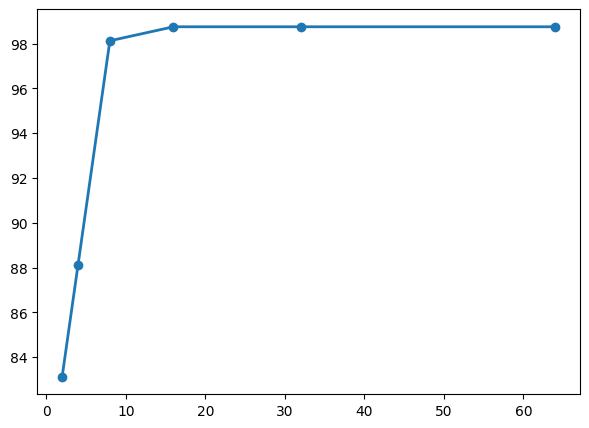

In [125]:
plt.figure(figsize=(7,5))
plt.plot(neurons,accuracy, marker='o', linewidth=2)
plt.title("Effect of Hidden Neurons on MLP Accuracy")
plt.title("Number o